In [52]:
import numpy as np
import matplotlib.pyplot as plt

In [53]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=500, noise=0.25, random_state=42)

Preprocessing

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_val, y_train, y_val = train_test_split(X, y, train_size=0.7, random_state=42)

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled, X_val_scaled = scaler.transform(X_train), scaler.transform(X_val)

Utility Functions

In [55]:
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))

def plot_svm(Z, kernel=None):
    fig, ax = plt.subplots()

    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X_val_scaled[:, 0], X_val_scaled[:, 1], c=y_val, cmap="coolwarm", edgecolors='k')
    if kernel is not None:
        plt.title(f'SVM Decision Boundary ({kernel.capitalize() if kernel.lower() != 'rbf' else kernel} Kernel)')
    else:
        plt.title("SVM Decision Boundary")
    plt.xlabel("Feature 1 (scaled)")
    plt.ylabel("Feature 2 (scaled)")
    plt.show()

    return fig

Model 1 - Linear Kernel

Accuracy: 0.8533333333333334

              precision    recall  f1-score   support

           0       0.84      0.87      0.86        75
           1       0.86      0.84      0.85        75

    accuracy                           0.85       150
   macro avg       0.85      0.85      0.85       150
weighted avg       0.85      0.85      0.85       150



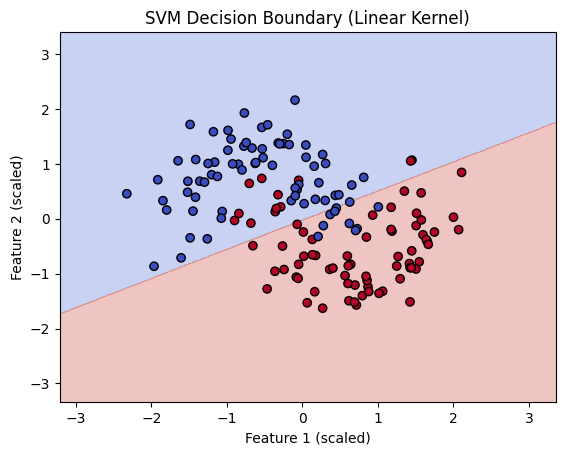

In [56]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

linear_model = SVC(kernel="linear", C=1.0, random_state=42)
linear_model.fit(X_train_scaled, y_train)

Z = linear_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z_linear = Z.reshape(xx.shape)

y_pred = linear_model.predict(X_val_scaled)
accuracy = accuracy_score(y_val, y_pred)
print(f'Accuracy: {accuracy}\n')
print(classification_report(y_val, y_pred))

fig_linear = plot_svm(Z_linear, "linear")


Model 2 - Polynomial Kernel

Accuracy: 0.8733333333333333

              precision    recall  f1-score   support

           0       0.83      0.93      0.88        75
           1       0.92      0.81      0.87        75

    accuracy                           0.87       150
   macro avg       0.88      0.87      0.87       150
weighted avg       0.88      0.87      0.87       150



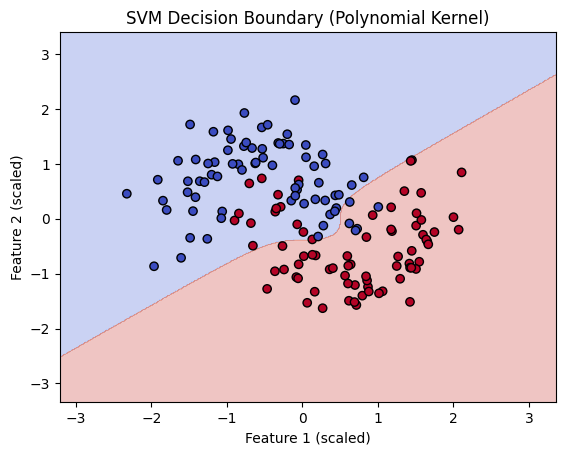

In [57]:
poly_model = SVC(kernel="poly", C=1.0, random_state=42)
poly_model.fit(X_train_scaled, y_train)

Z = poly_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z_poly = Z.reshape(xx.shape)

y_pred = poly_model.predict(X_val_scaled)
accuracy = accuracy_score(y_val, y_pred)
print(f'Accuracy: {accuracy}\n')
print(classification_report(y_val, y_pred))

fig_poly = plot_svm(Z_poly, "polynomial")


Model 3 - RBF Kernel

Accuracy: 0.9466666666666667

              precision    recall  f1-score   support

           0       0.91      0.99      0.95        75
           1       0.99      0.91      0.94        75

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150



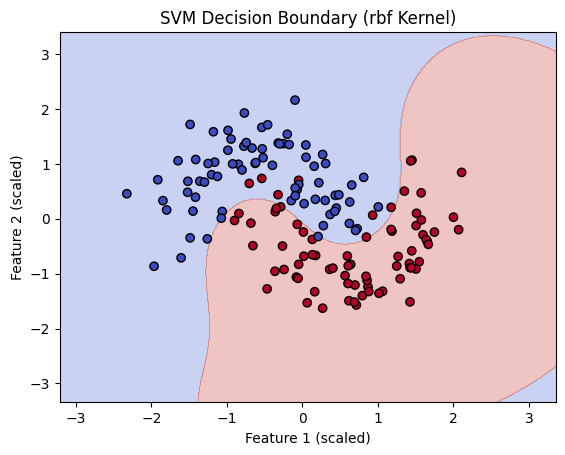

In [58]:
rbf_model = SVC(kernel="rbf", C=1, random_state=42)
rbf_model.fit(X_train_scaled, y_train)

Z = rbf_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z_rbf = Z.reshape(xx.shape)

y_pred = rbf_model.predict(X_val_scaled)
accuracy = accuracy_score(y_val, y_pred)
print(f'Accuracy: {accuracy}\n')
print(classification_report(y_val, y_pred))

fig_rbf = plot_svm(Z_rbf, "rbf")

Hyperparameter Tuning

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
Best Score: 0.9514285714285714
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        75
           1       1.00      0.93      0.97        75

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150



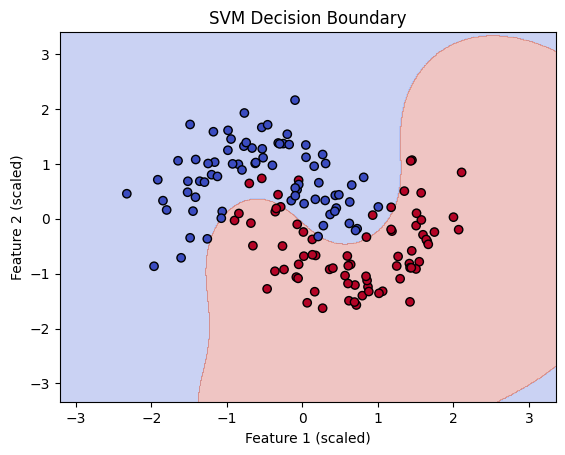

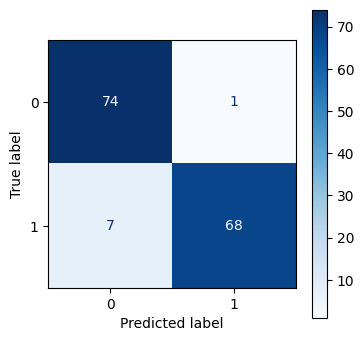

In [67]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.1, 1, 10, 100],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(random_state=42), param_grid, refit=True, verbose=1, cv=5, scoring='accuracy')

grid.fit(X_train_scaled, y_train)

Z = rbf_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z_best = Z.reshape(xx.shape)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

final_pred = grid.predict(X_val_scaled)
print(classification_report(y_val, final_pred))

fig_best = plot_svm(Z_best)

fig, ax = plt.subplots(figsize=(4, 4))
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap='Blues', ax=ax)
plt.show()


Comparison

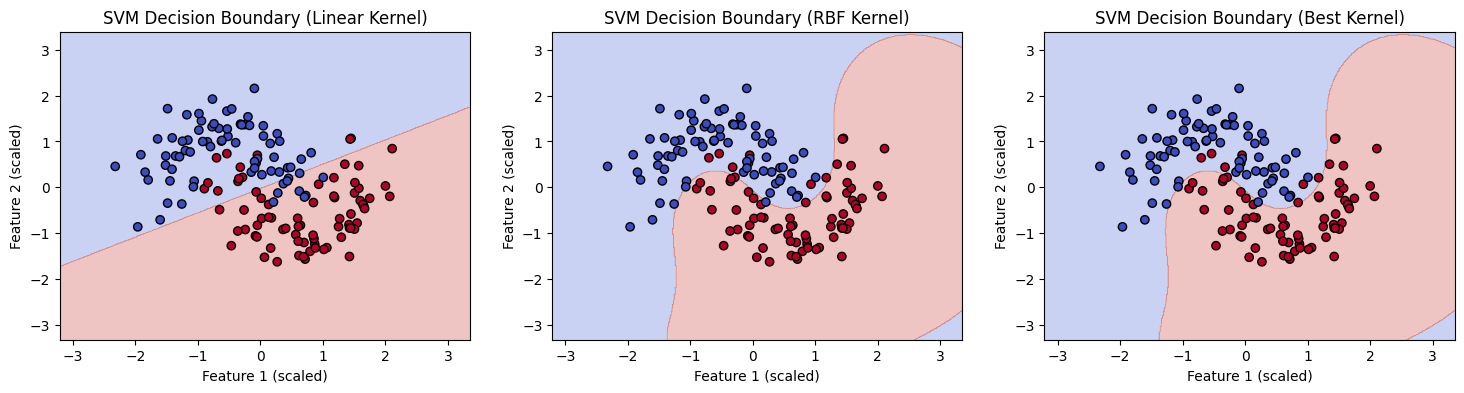

In [68]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4))

Z = [Z_linear, Z_rbf, Z_best]
kernels = ["linear", "rbf", "best"]

for i, (Z_val, kernel) in enumerate(zip(Z, kernels)):
    ax[i].contourf(xx, yy, Z_val, alpha=0.3, cmap='coolwarm')
    ax[i].scatter(X_val_scaled[:, 0], X_val_scaled[:, 1], c=y_val, cmap="coolwarm", edgecolors='k')
    ax[i].set_title(f'SVM Decision Boundary ({kernel.capitalize() if kernel.lower() != 'rbf' else kernel.upper()} Kernel)')
    ax[i].set_xlabel("Feature 1 (scaled)")
    ax[i].set_ylabel("Feature 2 (scaled)")

plt.show()